In [2]:
# %% [markdown]
# # 主流注意力机制性能分析实验
# 本实验对比 **MHA (多头注意力)**、**MQA (多查询注意力)**、**GQA (分组查询注意力)** 以及 **MLA (多头潜在注意力)** 的训练和推理性能。  
# 测量指标包括：前向+反向传播时间、峰值显存占用、KV缓存大小、解码步延迟。

# %%
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import gc
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple


In [3]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 检查 scaled_dot_product_attention 是否可用（PyTorch >= 2.0）
if not hasattr(F, 'scaled_dot_product_attention'):
    raise RuntimeError("请升级到 PyTorch >= 2.0，或自行实现 scaled_dot_product_attention 替换。")

# %% [markdown]
# ## 1. 注意力模块定义

# %%
class MultiHeadAttention(nn.Module):
    """标准多头注意力"""
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None, cache=None, use_cache=False):
        B, L, _ = x.shape
        q = self.W_q(x).view(B, L, self.n_heads, self.d_head).transpose(1, 2)
        k = self.W_k(x).view(B, L, self.n_heads, self.d_head).transpose(1, 2)
        v = self.W_v(x).view(B, L, self.n_heads, self.d_head).transpose(1, 2)
        if cache is not None:
            pk, pv = cache
            k = torch.cat([pk, k], dim=2)
            v = torch.cat([pv, v], dim=2)
        if use_cache:
            present_cache = (k, v)
        out = F.scaled_dot_product_attention(q, k, v, attn_mask=mask)
        out = out.transpose(1, 2).contiguous().view(B, L, self.d_model)
        out = self.W_o(out)
        return (out, present_cache) if use_cache else out


class MultiQueryAttention(nn.Module):
    """多查询注意力：所有头共享一组 K/V"""
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, self.d_head, bias=False)
        self.W_v = nn.Linear(d_model, self.d_head, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None, cache=None, use_cache=False):
        B, L, _ = x.shape
        q = self.W_q(x).view(B, L, self.n_heads, self.d_head).transpose(1, 2)
        k = self.W_k(x).unsqueeze(1)      # (B, 1, L, D)
        v = self.W_v(x).unsqueeze(1)
        if cache is not None:
            pk, pv = cache
            k = torch.cat([pk, k], dim=2)
            v = torch.cat([pv, v], dim=2)
        if use_cache:
            present_cache = (k, v)
        out = F.scaled_dot_product_attention(q, k, v, attn_mask=mask)
        out = out.transpose(1, 2).contiguous().view(B, L, self.d_model)
        out = self.W_o(out)
        return (out, present_cache) if use_cache else out


class GroupedQueryAttention(nn.Module):
    """分组查询注意力：将头分成若干组，组内共享 K/V"""
    def __init__(self, d_model, n_heads, n_kv_heads):
        super().__init__()
        assert d_model % n_heads == 0 and n_heads % n_kv_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads
        self.d_head = d_model // n_heads
        self.n_rep = n_heads // n_kv_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, n_kv_heads * self.d_head, bias=False)
        self.W_v = nn.Linear(d_model, n_kv_heads * self.d_head, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None, cache=None, use_cache=False):
        B, L, _ = x.shape
        q = self.W_q(x).view(B, L, self.n_heads, self.d_head).transpose(1, 2)
        k = self.W_k(x).view(B, L, self.n_kv_heads, self.d_head).transpose(1, 2)
        v = self.W_v(x).view(B, L, self.n_kv_heads, self.d_head).transpose(1, 2)
        if cache is not None:
            pk, pv = cache
            k = torch.cat([pk, k], dim=2)
            v = torch.cat([pv, v], dim=2)
        if use_cache:
            present_cache = (k, v)
        # 广播以匹配 query 头数
        k = k.repeat_interleave(self.n_rep, dim=1)
        v = v.repeat_interleave(self.n_rep, dim=1)
        out = F.scaled_dot_product_attention(q, k, v, attn_mask=mask)
        out = out.transpose(1, 2).contiguous().view(B, L, self.d_model)
        out = self.W_o(out)
        return (out, present_cache) if use_cache else out


class MultiHeadLatentAttention(nn.Module):
    """多头潜在注意力 (DeepSeek-V2 风格)：对 K/V 进行低秩压缩以减少 KV 缓存"""
    def __init__(self, d_model, n_heads, d_latent):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.d_latent = d_latent
        # K/V 压缩
        self.W_dkv = nn.Linear(d_model, d_latent, bias=False)   # 下投影
        self.W_uk  = nn.Linear(d_latent, n_heads * self.d_head, bias=False)  # key 上投影
        self.W_uv  = nn.Linear(d_latent, n_heads * self.d_head, bias=False)  # value 上投影
        # Q 保持标准投影
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None, cache=None, use_cache=False):
        B, L, _ = x.shape
        q = self.W_q(x).view(B, L, self.n_heads, self.d_head).transpose(1, 2)
        c_kv = self.W_dkv(x)                     # (B, L, d_latent)
        if cache is not None:
            c_kv = torch.cat([cache, c_kv], dim=1)  # 沿序列长度拼接
        if use_cache:
            present_cache = c_kv                 # 缓存压缩潜向量
        # 上投影得到完整的 K, V
        k = self.W_uk(c_kv).view(B, -1, self.n_heads, self.d_head).transpose(1, 2)
        v = self.W_uv(c_kv).view(B, -1, self.n_heads, self.d_head).transpose(1, 2)
        out = F.scaled_dot_product_attention(q, k, v, attn_mask=mask)
        out = out.transpose(1, 2).contiguous().view(B, L, self.d_model)
        out = self.W_o(out)
        return (out, present_cache) if use_cache else out

# %% [markdown]
# ## 2. 性能测试辅助函数

# %%
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def measure_training_step(model, x, mask=None, warmup=10, repeat=50):
    """测量一次训练步骤（前向+反向）的时间和峰值显存"""
    model.train()
    # 创建一个不更新参数的优化器，仅用于清零梯度
    optimizer = torch.optim.SGD(model.parameters(), lr=0.0)
    for _ in range(warmup):
        optimizer.zero_grad()
        out = model(x, mask=mask)
        out.sum().backward()
    if device.type == 'cuda':
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        times, mems = [], []
    else:
        times = []
        repeat = 3  # CPU 上减少重复次数

    for _ in range(repeat):
        optimizer.zero_grad()
        if device.type == 'cuda':
            start.record()
        else:
            t0 = time.time()
        out = model(x, mask=mask)
        loss = out.sum()
        loss.backward()
        if device.type == 'cuda':
            end.record()
            torch.cuda.synchronize()
            times.append(start.elapsed_time(end))
            mems.append(torch.cuda.max_memory_allocated() / 1024**2)   # MB
        else:
            times.append((time.time() - t0) * 1000)
    avg_time = np.mean(times)
    avg_mem = np.mean(mems) if device.type == 'cuda' else 0.0
    return avg_time, avg_mem

def measure_prefill(model, x, mask=None):
    """测量预填充阶段的时间、峰值内存，并返回缓存"""
    model.eval()
    with torch.no_grad():
        if device.type == 'cuda':
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats()
            start = torch.cuda.Event(enable_timing=True)
            end = torch.cuda.Event(enable_timing=True)
            start.record()
        else:
            t0 = time.time()
        out, cache = model(x, mask=mask, use_cache=True)
        if device.type == 'cuda':
            end.record()
            torch.cuda.synchronize()
            time_ms = start.elapsed_time(end)
            mem_peak = torch.cuda.max_memory_allocated() / 1024**2
        else:
            time_ms = (time.time() - t0) * 1000
            mem_peak = 0.0
    return time_ms, mem_peak, cache

def measure_decode_step(model, token, cache, mask=None):
    """测量单个解码步的时间，返回新缓存"""
    model.eval()
    with torch.no_grad():
        if device.type == 'cuda':
            torch.cuda.synchronize()
            start = torch.cuda.Event(enable_timing=True)
            end = torch.cuda.Event(enable_timing=True)
            start.record()
        else:
            t0 = time.time()
        out, new_cache = model(token, mask=mask, cache=cache, use_cache=True)
        if device.type == 'cuda':
            end.record()
            torch.cuda.synchronize()
            time_ms = start.elapsed_time(end)
        else:
            time_ms = (time.time() - t0) * 1000
    return time_ms, new_cache

def get_cache_size(cache):
    """计算缓存占用的字节数"""
    if isinstance(cache, tuple):
        return sum(t.element_size() * t.numel() for t in cache)
    return cache.element_size() * cache.numel()


Using device: cuda


In [4]:

# %% [markdown]
# ## 3. 实验配置与模型实例化

# %%
# 基础配置
d_model = 1024
n_heads = 16
d_head = d_model // n_heads        # 64
n_kv_heads_gqa = 4                # GQA 的 KV 头数
d_latent_mla = d_model // 4       # MLA 压缩维度 = 256
batch_size = 2
seq_lengths = [128, 256, 512, 1024]
prompt_len = 512                  # 推理预填充长度

# 实例化模型
mha = MultiHeadAttention(d_model, n_heads).to(device)
mqa = MultiQueryAttention(d_model, n_heads).to(device)
gqa = GroupedQueryAttention(d_model, n_heads, n_kv_heads_gqa).to(device)
mla = MultiHeadLatentAttention(d_model, n_heads, d_latent_mla).to(device)

models = {
    'MHA': mha,
    'MQA': mqa,
    'GQA': gqa,
    'MLA': mla,
}

print("=== 模型参数量 ===")
for name, model in models.items():
    print(f"{name}: {count_parameters(model):,}")


=== 模型参数量 ===
MHA: 4,194,304
MQA: 2,228,224
GQA: 2,621,440
MLA: 2,883,584


In [5]:

# %% [markdown]
# ## 4. 训练性能对比（不同序列长度）

# %%
train_results = {name: {'times': [], 'mems': []} for name in models}

for seq_len in seq_lengths:
    x = torch.randn(batch_size, seq_len, d_model, device=device)
    # 因果 mask
    mask = torch.triu(torch.ones(seq_len, seq_len, device=device) * float('-inf'), diagonal=1)
    mask = mask.unsqueeze(0).unsqueeze(0)   # (1, 1, L, L)

    print(f"\nSeq length = {seq_len}")
    for name, model in models.items():
        try:
            avg_time, avg_mem = measure_training_step(model, x, mask, warmup=5, repeat=20)
            train_results[name]['times'].append(avg_time)
            train_results[name]['mems'].append(avg_mem)
            print(f"  {name}: time = {avg_time:.2f} ms, peak mem = {avg_mem:.2f} MB")
        except RuntimeError as e:
            print(f"  {name}: OOM or error - {e}")
            train_results[name]['times'].append(None)
            train_results[name]['mems'].append(None)
    if device.type == 'cuda':
        torch.cuda.empty_cache()



Seq length = 128
  MHA: time = 2.54 ms, peak mem = 80.81 MB
  MQA: time = 4.92 ms, peak mem = 93.88 MB
  GQA: time = 4.39 ms, peak mem = 102.34 MB
  MLA: time = 4.15 ms, peak mem = 112.59 MB

Seq length = 256
  MHA: time = 3.62 ms, peak mem = 117.59 MB
  MQA: time = 5.31 ms, peak mem = 143.13 MB
  GQA: time = 4.19 ms, peak mem = 123.59 MB
  MLA: time = 4.16 ms, peak mem = 123.09 MB

Seq length = 512
  MHA: time = 3.85 ms, peak mem = 140.44 MB
  MQA: time = 5.40 ms, peak mem = 248.00 MB
  GQA: time = 4.22 ms, peak mem = 146.44 MB
  MLA: time = 4.01 ms, peak mem = 146.44 MB

Seq length = 1024
  MHA: time = 7.35 ms, peak mem = 187.63 MB
  MQA: time = 7.51 ms, peak mem = 651.25 MB
  GQA: time = 6.87 ms, peak mem = 193.63 MB
  MLA: time = 7.08 ms, peak mem = 194.63 MB


In [19]:

# %% [markdown]
# ## 5. 推理性能对比（预填充 + 单步解码 + 缓存大小）

# %%
x_prompt = torch.randn(batch_size, prompt_len, d_model, device=device)
mask_prompt = torch.triu(torch.ones(prompt_len, prompt_len, device=device) * float('-inf'), diagonal=1)
mask_prompt = mask_prompt.unsqueeze(0).unsqueeze(0)

x_token = torch.randn(batch_size, 1, d_model, device=device)   # 当前解码 token

prefill_results = {}
decode_results = {}
cache_sizes = {}

print("\n=== 推理性能 (prompt length = 512) ===")
print(f"|{'model':^6}| {'Prefill time':^20} | {'peak mem':^15} | {'KV cache size':^20} | {'Decode step time':^20} |")
for name, model in models.items():
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    try:
        t_prefill, mem_prefill, cache = measure_prefill(model, x_prompt, mask=mask_prompt)
        prefill_results[name] = (t_prefill, mem_prefill)
        cache_sizes[name] = get_cache_size(cache)

        t_decode, _ = measure_decode_step(model, x_token, cache)
        decode_results[name] = t_decode
        line = (f"|{name:^6}| {t_prefill:^17.2f} ms | {mem_prefill:^12.2f} MB | {cache_sizes[name]/1024**2:^17.4f} MB | {t_decode:^17.2f} ms |")
        print(line)
    except RuntimeError as e:
        print(f"{name}: OOM or error - {e}")
        prefill_results[name] = (None, None)
        decode_results[name] = None
        cache_sizes[name] = None



=== 推理性能 (prompt length = 512) ===
|model |     Prefill time     |    peak mem     |    KV cache size     |   Decode step time   |
| MHA  |       2.00        ms |    147.13    MB |      8.0000       MB |       0.58        ms |
| MQA  |       1.73        ms |    253.65    MB |      0.5000       MB |       0.98        ms |
| GQA  |       1.19        ms |    148.13    MB |      2.0000       MB |       0.52        ms |
| MLA  |       0.81        ms |    150.13    MB |      1.0000       MB |       0.45        ms |


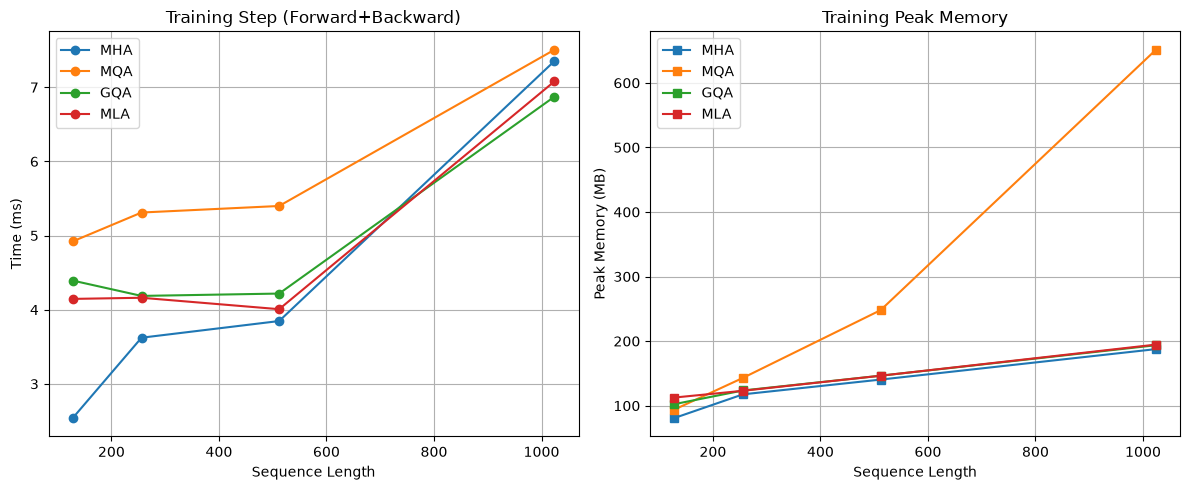

In [7]:

# %% [markdown]
# ## 6. 可视化

# %%
# ---------- 训练性能 ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for name in models:
    times = train_results[name]['times']
    if all(t is not None for t in times):
        ax.plot(seq_lengths, times, marker='o', label=name)
ax.set_xlabel('Sequence Length')
ax.set_ylabel('Time (ms)')
ax.set_title('Training Step (Forward+Backward)')
ax.legend()
ax.grid(True)

ax = axes[1]
for name in models:
    mems = train_results[name]['mems']
    if all(m is not None for m in mems):
        ax.plot(seq_lengths, mems, marker='s', label=name)
ax.set_xlabel('Sequence Length')
ax.set_ylabel('Peak Memory (MB)')
ax.set_title('Training Peak Memory')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


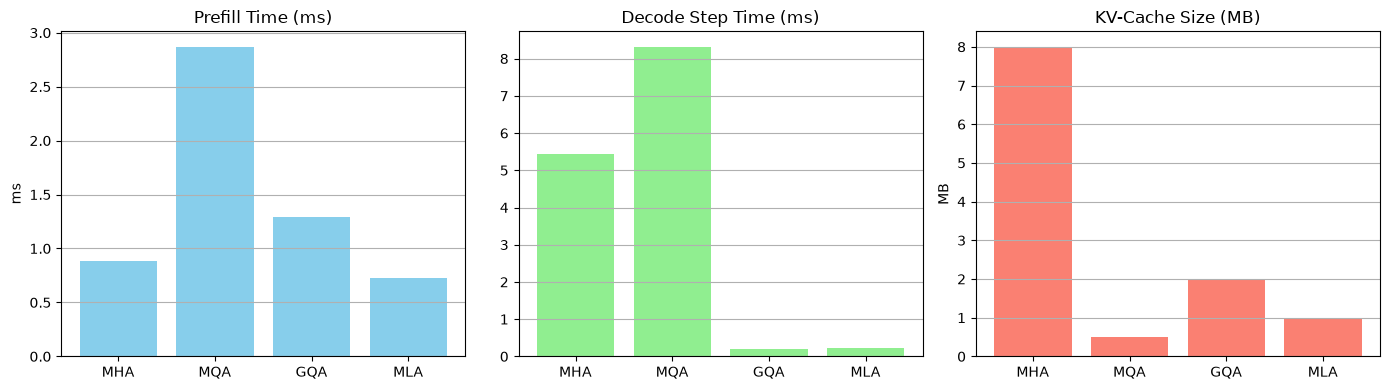

In [8]:

# %%
# ---------- 推理性能 ----------
names = list(models.keys())
prefill_times = [prefill_results[n][0] if prefill_results[n][0] is not None else 0 for n in names]
decode_times   = [decode_results[n] if decode_results[n] is not None else 0 for n in names]
cache_mb       = [cache_sizes[n]/1024**2 if cache_sizes[n] is not None else 0 for n in names]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(names, prefill_times, color='skyblue')
axes[0].set_title('Prefill Time (ms)')
axes[0].set_ylabel('ms')
axes[0].grid(axis='y')

axes[1].bar(names, decode_times, color='lightgreen')
axes[1].set_title('Decode Step Time (ms)')
axes[1].grid(axis='y')

axes[2].bar(names, cache_mb, color='salmon')
axes[2].set_title('KV-Cache Size (MB)')
axes[2].set_ylabel('MB')
axes[2].grid(axis='y')

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 7. 结论摘要
# - **MHA**：训练/推理计算量最大，KV缓存最高（线性正比于头数）。
# - **MQA**：极大减少了KV缓存，但可能略微影响模型容量；训练时间因K/V广播略有不同。
# - **GQA**：在缓存和容量之间取得平衡。
# - **MLA**：通过低秩压缩将KV缓存降为潜向量，缓存大小仅取决于压缩维度；但解码时需要从潜向量重建K/V，增加了一步计算开销，因此解码延迟可能高于MQA/GQA。训练参数量可通过调整压缩率控制。
# 
# *实际表现受硬件、序列长度和具体实现细节影响，本实验提供基本性能趋势参考。*